In [1]:
include("../bracelets.jl")
using BenchmarkTools, Plots, ProgressMeter, Distributions, StatsBase

## Starting at rotation by 1 (n prime)

In [ ]:
p = 349
m = 1
n = p^m
reps = 20
n_samples = 10000
samples = zeros(Int, n_samples, reps)
@showprogress for i in 1:n_samples
    _, js, rs = burnside_process(n, reps)
    samples[i, 1:reps] = n .* rs .+ js
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


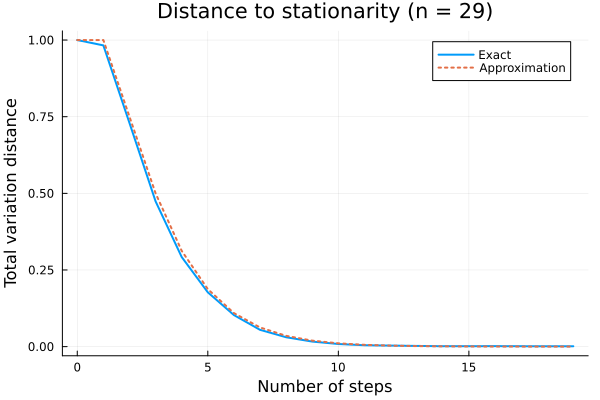

In [ ]:
vals = 0:(2*n-1)
emperical_dist_ = sum(samples .== reshape(vals, 1, 1, :), dims = 1)./n_samples
emperical_dist = dropdims(emperical_dist_, dims=1)
stationary_dist = π(n, 2)
TV_dist = sum(abs.(emperical_dist .- reshape(stationary_dist,1,:)), dims = 2)/2
ts = 0:(reps-1)
nbin = NegativeBinomial(2, 1-1/2)
approx = 1 .- cdf(nbin, ts .- 2)

plt = plot(ts, TV_dist, label="Exact", linewidth = 2)
plot!(plt, ts, approx, label="Approximation",linewidth = 2, linestyle = :dot)
xlabel!(plt, "Number of steps")
ylabel!(plt, "Total variation distance")
title!(plt, "Distance to stationarity (Dihedral group, n = 29)")
plt

## Starting at rotation by 1 (n composite)

In [10]:
n = 360
k = 2
reps = 20
n_samples = 10000
samples = zeros(Int, n_samples, reps)
@showprogress for i in 1:n_samples
    _, js, rs = burnside_process(n, reps, k)
    samples[i, 1:reps] = n .* rs .+ js
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:59


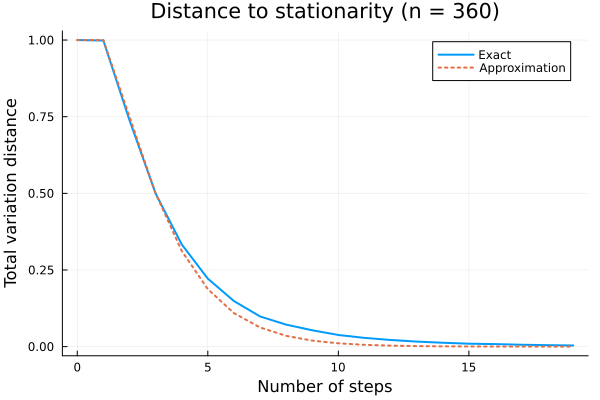

In [11]:
vals = 0:(2*n-1)
emperical_dist = zeros(reps, 2*n)
for i in 1:reps
    emperical_dist[i, 1:end] = proportions(samples[1:end,i], vals) 
end
stationary_dist = π(n, k)
TV_dist = sum(abs.(emperical_dist .- reshape(stationary_dist,1,:)), dims = 2)/2
ts = 0:(reps-1)

c = (1- 2^(-n/4))/4
approx = (1 - c) .^ (ts .÷ 2)

nbin = NegativeBinomial(2, 1-1/2)
approx = 1 .- cdf(nbin, ts .- 2)

plt = plot(ts, TV_dist, label="Exact", linewidth = 2)
plot!(plt, ts, approx, label="Approximation",linewidth = 2, linestyle = :dot)
xlabel!(plt, "Number of steps")
ylabel!(plt, "Total variation distance")
title!(plt, "Distance to stationarity (n = 360)")
plt

## Considering different starting states

In [7]:
function compute_TV(samples, n, k)
    n_samples, reps = size(samples)
    emperical_dist = zeros((reps, 2*n))
    vals = 0:(2*n-1)
    for i in 1:reps
        emperical_dist[i, 1:end] = proportions(samples[1:end,i], vals) 

    end
    stationary_dist = π(n, k)
    TV = sum(abs.(emperical_dist .- reshape(stationary_dist,1,:)), dims = 2)/2
    return TV
end


compute_TV (generic function with 1 method)

In [17]:
n = 120
k = 2
reps = 20
j0s = 0:(n-1)
r0s = 0:1
n_samples = 10000
TV_dists = zeros(2*n, reps)
@showprogress for j0 in j0s, r0 in r0s
    samples = zeros(Int, n_samples, reps)
    for i in 1:n_samples
        _, js, rs = burnside_process(n, reps, k, j0, r0)
        samples[i, 1:reps] = n .* rs .+ js
    end
    TV_dists[n * r0 + j0 + 1, 1:end] = compute_TV(samples, n, k)
end


Progress: 100%|█████████████████████████████████████████| Time: 0:22:37


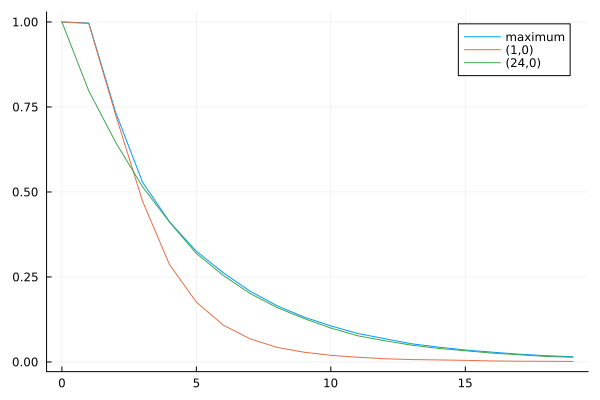

In [18]:
ts = 0:(reps-1)
plt = plot(ts, maximum(TV_dists, dims = 1)', label = "maximum")
plot!(plt, ts, TV_dists[2,1:end], label ="(1,0)")
plot!(plt, ts, TV_dists[25,1:end], label ="(24,0)")

In [77]:
n = 18
k = 2
reps = 20
j0s = 0:(n-1)
r0s = 0:1
n_samples = 1000
TV_dists = zeros(2*n, reps)
@showprogress for j0 in j0s, r0 in r0s
    samples = zeros(Int, n_samples, reps)
    for i in 1:n_samples
        _, js, rs = burnside_process(n, reps, k, j0, r0)
        samples[i, 1:reps] = n .* rs .+ js
    end
    TV_dists[n * r0 + j0 + 1, 1:end] = compute_TV(samples, n, k)
end


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


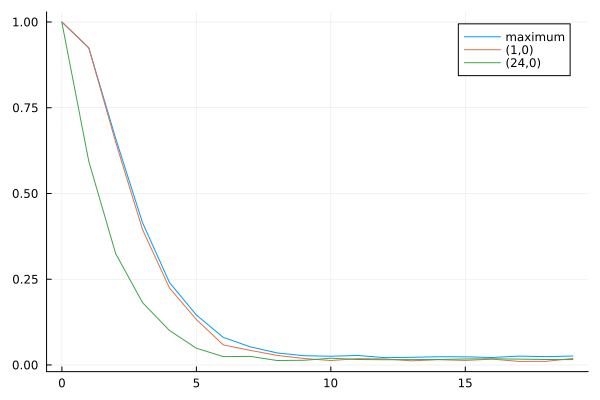

In [82]:
ts = 0:(reps-1)
plt = plot(ts, maximum(TV_dists, dims = 1)', label = "maximum")
plot!(plt, ts, TV_dists[2,1:end], label ="(1,0)")
plot!(plt, ts, TV_dists[10,1:end], label ="(24,0)")

In [79]:
for c in argmax(TV_dists, dims = 1)
    println(gcd(c[1]-1,n))
end

1
1
2
2
2
2
2
3
3
1
3
2
1
2
2
9
9
9
9
2


In [60]:
n = 60
j = 12
r = 0
k = 2
x = zeros(reps, n)
for i in 1:reps
    x[i, 1:n] = sample_fixed_point(j, r, n, k)
end

In [84]:
n = 6
j = n ÷ 2
r = 0 
k = 3
reps = 100
for i in 1:reps
    x = sample_fixed_point(j, r, n, k)
    symmetric = false
    for l in 1:n 
        if is_fixed(x,l,1)
            symmetric = true
            break
        end
    end
    if symmetric == false
        println(x)
        break
    end
end

[1, 2, 0, 1, 2, 0]


In [71]:
x

30-element Vector{Int64}:
 0
 0
 1
 0
 1
 1
 0
 0
 1
 0
 ⋮
 0
 1
 1
 0
 0
 1
 0
 1
 1